In [28]:
from torchvision import datasets, transforms

IMAGE_SIZE = 128

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

test_dataset = datasets.Flowers102(
    root="./data",
    split="train",
    transform=transform,
    download=True
)

print("Number of training images:", len(test_dataset))

Number of training images: 1020


In [29]:
validation_dataset = datasets.Flowers102(
    root="./data",
    split="val",
    transform=transform,
    download=True
)

train_dataset = datasets.Flowers102(
    root="./data",
    split="test",
    transform=transform,
    download=True
)

print("Training images:", len(train_dataset))
print("Validation images:", len(validation_dataset))
print("Testing images:", len(test_dataset))
print("Total images:", len(train_dataset) + len(validation_dataset) + len(test_dataset))

Training images: 6149
Validation images: 1020
Testing images: 1020
Total images: 8189


Image shape: torch.Size([3, 128, 128])
Class number: 0


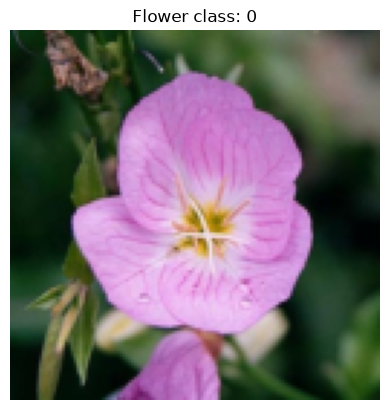

In [34]:
import matplotlib.pyplot as plt

image, label = train_dataset[0]

print("Image shape:", image.shape)
print("Class number:", label)

plt.imshow(image.permute(1, 2, 0))
plt.title(f"Flower class: {label}")
plt.axis("off")
plt.show()

In [35]:
image, label = train_dataset[0]

In [36]:
image.shape

torch.Size([3, 128, 128])

In [39]:
label

0

In [40]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(validation_loader))
print("Testing batches:", len(test_loader))

Training batches: 193
Validation batches: 32
Testing batches: 32


In [41]:
import torch
import torch.nn as nn

class FlowerCNN(nn.Module):

    def __init__(self):
        super(FlowerCNN, self).__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128 * 16 * 16,
                256
            ),

            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(
                256,
                102
            )
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [42]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = FlowerCNN()
model = model.to(device)

print(model)
print("Device:", device)

FlowerCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=102, bias=True)
  )
)
Device: cpu


In [43]:
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

outputs = model(images)

print("Input shape:", images.shape)
print("Labels shape:", labels.shape)
print("Output shape:", outputs.shape)

Input shape: torch.Size([32, 3, 128, 128])
Labels shape: torch.Size([32])
Output shape: torch.Size([32, 102])


In [44]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer created successfully")

Loss function: CrossEntropyLoss()
Optimizer created successfully


In [45]:
EPOCHS = 1

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0.0
    correct_predictions = 0
    total_images = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted_classes = torch.max(outputs, 1)

        total_images += labels.size(0)

        correct_predictions += (
            predicted_classes == labels
        ).sum().item()

    training_loss = running_loss / len(train_loader)

    training_accuracy = (
        100 * correct_predictions / total_images
    )

    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print(f"Training loss: {training_loss:.4f}")
    print(f"Training accuracy: {training_accuracy:.2f}%")

Epoch 1/1
Training loss: 4.1295
Training accuracy: 7.97%


In [46]:
EPOCHS = 10

train_losses = []
train_accuracies = []
validation_losses = []
validation_accuracies = []

for epoch in range(EPOCHS):

    # -------------------------
    # Training
    # -------------------------
    model.train()

    running_train_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

        _, predictions = torch.max(outputs, 1)

        total_train += labels.size(0)
        correct_train += (predictions == labels).sum().item()

    train_loss = running_train_loss / len(train_loader)
    train_accuracy = 100 * correct_train / total_train

    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    running_validation_loss = 0.0
    correct_validation = 0
    total_validation = 0

    with torch.no_grad():

        for images, labels in validation_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_validation_loss += loss.item()

            _, predictions = torch.max(outputs, 1)

            total_validation += labels.size(0)
            correct_validation += (
                predictions == labels
            ).sum().item()

    validation_loss = (
        running_validation_loss / len(validation_loader)
    )

    validation_accuracy = (
        100 * correct_validation / total_validation
    )

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    validation_losses.append(validation_loss)
    validation_accuracies.append(validation_accuracy)

    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print(f"Training loss: {train_loss:.4f}")
    print(f"Training accuracy: {train_accuracy:.2f}%")
    print(f"Validation loss: {validation_loss:.4f}")
    print(f"Validation accuracy: {validation_accuracy:.2f}%")
    print("-" * 40)

Epoch 1/10
Training loss: 3.4578
Training accuracy: 16.43%
Validation loss: 3.5455
Validation accuracy: 11.18%
----------------------------------------
Epoch 2/10
Training loss: 3.0987
Training accuracy: 22.05%
Validation loss: 3.1836
Validation accuracy: 17.45%
----------------------------------------
Epoch 3/10
Training loss: 2.8414
Training accuracy: 27.29%
Validation loss: 3.0428
Validation accuracy: 21.96%
----------------------------------------
Epoch 4/10
Training loss: 2.5746
Training accuracy: 32.35%
Validation loss: 2.8607
Validation accuracy: 24.71%
----------------------------------------
Epoch 5/10
Training loss: 2.3229
Training accuracy: 37.99%
Validation loss: 2.7163
Validation accuracy: 28.43%
----------------------------------------
Epoch 6/10
Training loss: 2.0918
Training accuracy: 42.74%
Validation loss: 2.6620
Validation accuracy: 31.47%
----------------------------------------
Epoch 7/10
Training loss: 1.9159
Training accuracy: 47.21%
Validation loss: 2.5311
Valid

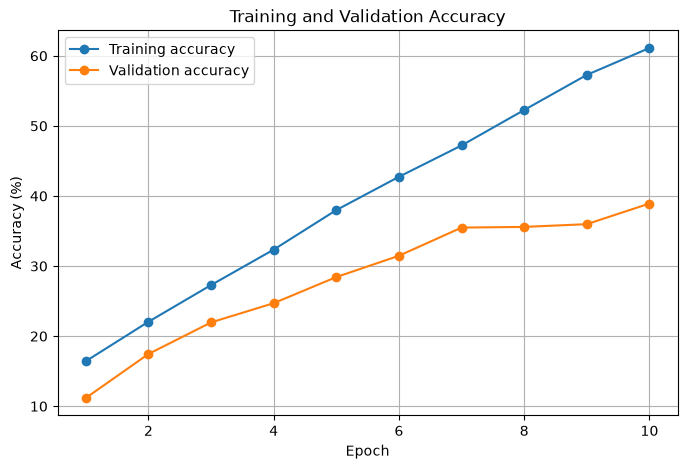

In [47]:
import matplotlib.pyplot as plt

epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_accuracies, marker="o", label="Training accuracy")
plt.plot(epochs, validation_accuracies, marker="o", label="Validation accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

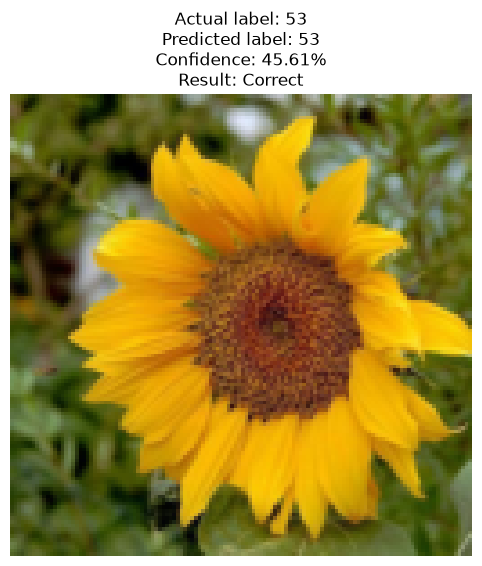

Test image index: 538
Actual label: 53
Predicted label: 53
Confidence: 45.61%
Correct prediction: True


In [57]:
import random
import torch
import matplotlib.pyplot as plt

# Put the model in evaluation mode
model.eval()

# Select a random image from the test dataset
random_index = random.randint(0, len(test_dataset) - 1)

image, actual_label = test_dataset[random_index]

# Add a batch dimension:
# [3, 128, 128] becomes [1, 3, 128, 128]
input_image = image.unsqueeze(0).to(device)

# Make the prediction without calculating gradients
with torch.no_grad():
    output = model(input_image)

    # Convert output scores into probabilities
    probabilities = torch.softmax(output, dim=1)

    # Get the class with the highest probability
    predicted_label = torch.argmax(probabilities, dim=1).item()

    # Get the confidence of that prediction
    confidence = probabilities[0, predicted_label].item() * 100


# Undo normalization so the image displays correctly
# mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
# std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

# display_image = image.cpu() * std + mean
# display_image = torch.clamp(display_image, 0, 1)


# Check whether the prediction is correct
is_correct = predicted_label == actual_label

# Display the image and result
plt.figure(figsize=(6, 6))
plt.imshow(image.cpu().permute(1, 2, 0))

plt.title(
    f"Actual label: {actual_label}\n"
    f"Predicted label: {predicted_label}\n"
    f"Confidence: {confidence:.2f}%\n"
    f"Result: {'Correct' if is_correct else 'Incorrect'}"
)

plt.axis("off")
plt.show()

print("Test image index:", random_index)
print("Actual label:", actual_label)
print("Predicted label:", predicted_label)
print(f"Confidence: {confidence:.2f}%")
print("Correct prediction:", is_correct)

In [58]:
print("Training images:", len(train_dataset))
print("Validation images:", len(validation_dataset))
print("Testing images:", len(test_dataset))

images, labels = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)

Training images: 6149
Validation images: 1020
Testing images: 1020
Batch image shape: torch.Size([32, 3, 128, 128])
Batch label shape: torch.Size([32])


In [61]:
from torchvision import transforms

IMAGE_SIZE = 128

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(0.75, 1.0)
    ),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

evaluation_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms created successfully")

Transforms created successfully


In [63]:
train_dataset = datasets.Flowers102(
    root="./data",
    split="train",
    transform=train_transform,
    download=False
)

validation_dataset = datasets.Flowers102(
    root="./data",
    split="val",
    transform=evaluation_transform,
    download=False
)

test_dataset = datasets.Flowers102(
    root="./data",
    split="test",
    transform=evaluation_transform,
    download=False
)

In [64]:
print("Training images:", len(train_dataset))
print("Validation images:", len(validation_dataset))
print("Testing images:", len(test_dataset))

Training images: 1020
Validation images: 1020
Testing images: 6149


In [65]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(validation_loader))
print("Testing batches:", len(test_loader))

Training batches: 32
Validation batches: 32
Testing batches: 193


In [66]:
import torch
import torch.nn as nn


class FlowerANN(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(

            nn.Flatten(),

            nn.Linear(3 * 128 * 128, 512),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(256, 102)
        )

    def forward(self, x):
        return self.network(x)

In [67]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

ann_model = FlowerANN().to(device)

print(ann_model)
print("Device:", device)

FlowerANN(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=49152, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.5, inplace=False)
    (7): Linear(in_features=256, out_features=102, bias=True)
  )
)
Device: cpu


In [68]:
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

outputs = ann_model(images)

print("Input shape:", images.shape)
print("Labels shape:", labels.shape)
print("ANN output shape:", outputs.shape)

Input shape: torch.Size([32, 3, 128, 128])
Labels shape: torch.Size([32])
ANN output shape: torch.Size([32, 102])


In [69]:
ann_criterion = nn.CrossEntropyLoss()

ann_optimizer = torch.optim.Adam(
    ann_model.parameters(),
    lr=0.0005,
    weight_decay=0.0001
)

print("ANN loss function:", ann_criterion)
print("ANN optimizer created successfully")

ANN loss function: CrossEntropyLoss()
ANN optimizer created successfully


In [71]:
ANN_EPOCHS = 1

for epoch in range(ANN_EPOCHS):

    ann_model.train()

    running_loss = 0.0
    correct_predictions = 0
    total_images = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Remove gradients from the previous batch
        ann_optimizer.zero_grad()

        # Pass images through the ANN
        outputs = ann_model(images)

        # Calculate the error
        loss = ann_criterion(outputs, labels)

        # Calculate gradients
        loss.backward()

        # Update the ANN weights
        ann_optimizer.step()

        running_loss += loss.item()

        _, predicted_classes = torch.max(outputs, dim=1)

        total_images += labels.size(0)

        correct_predictions += (
            predicted_classes == labels
        ).sum().item()

    average_loss = running_loss / len(train_loader)

    training_accuracy = (
        100 * correct_predictions / total_images
    )

    print(f"Epoch {epoch + 1}/{ANN_EPOCHS}")
    print(f"ANN training loss: {average_loss:.4f}")
    print(f"ANN training accuracy: {training_accuracy:.2f}%")

Epoch 1/1
ANN training loss: 5.0999
ANN training accuracy: 1.57%


In [76]:
import torch
import torch.nn as nn

from torchvision.models import resnet18, ResNet18_Weights

weights = ResNet18_Weights.DEFAULT

transfer_model = resnet18(weights=weights)

print("Pretrained ResNet18 loaded successfully")

Pretrained ResNet18 loaded successfully


In [77]:
transfer_model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [78]:
for parameter in transfer_model.parameters():
    parameter.requires_grad = False

print("All pretrained layers are frozen")

All pretrained layers are frozen


In [79]:
transfer_model.fc

Linear(in_features=512, out_features=1000, bias=True)

In [80]:
number_of_features = transfer_model.fc.in_features

transfer_model.fc = nn.Linear(
    number_of_features,
    102
)

print("Input features:", number_of_features)
print("Output classes:", transfer_model.fc.out_features)

Input features: 512
Output classes: 102


In [81]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

transfer_model = transfer_model.to(device)

print("Device:", device)
print(transfer_model.fc)

Device: cpu
Linear(in_features=512, out_features=102, bias=True)


In [82]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)

Image batch shape: torch.Size([32, 3, 128, 128])


In [83]:
images = images.to(device)
labels = labels.to(device)

outputs = transfer_model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)

Input shape: torch.Size([32, 3, 128, 128])
Output shape: torch.Size([32, 102])


In [84]:
transfer_criterion = nn.CrossEntropyLoss()

transfer_optimizer = torch.optim.Adam(
    transfer_model.fc.parameters(),
    lr=0.001
)

print("Loss function created successfully")
print("Optimizer created successfully")

Loss function created successfully
Optimizer created successfully


In [85]:
transfer_criterion = nn.CrossEntropyLoss()

transfer_optimizer = torch.optim.Adam(
    transfer_model.fc.parameters(),
    lr=0.001
)

print("Loss function created successfully")
print("Optimizer created successfully")

Loss function created successfully
Optimizer created successfully


In [86]:
TRANSFER_EPOCHS = 1

for epoch in range(TRANSFER_EPOCHS):

    transfer_model.train()

    running_loss = 0.0
    correct_predictions = 0
    total_images = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Clear gradients from the previous batch
        transfer_optimizer.zero_grad()

        # Forward pass
        outputs = transfer_model(images)

        # Calculate loss
        loss = transfer_criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update the new final layer
        transfer_optimizer.step()

        running_loss += loss.item()

        _, predictions = torch.max(outputs, dim=1)

        total_images += labels.size(0)

        correct_predictions += (
            predictions == labels
        ).sum().item()

    average_loss = running_loss / len(train_loader)

    training_accuracy = (
        100 * correct_predictions / total_images
    )

    print(f"Epoch {epoch + 1}/{TRANSFER_EPOCHS}")
    print(f"Training loss: {average_loss:.4f}")
    print(f"Training accuracy: {training_accuracy:.2f}%")

Epoch 1/1
Training loss: 4.6884
Training accuracy: 4.22%


In [88]:
TRANSFER_EPOCHS = 10

transfer_train_losses = []
transfer_train_accuracies = []
transfer_validation_losses = []
transfer_validation_accuracies = []

best_validation_accuracy = 0.0

for epoch in range(TRANSFER_EPOCHS):

    # -------------------------
    # Training
    # -------------------------
    transfer_model.train()

    running_train_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        transfer_optimizer.zero_grad()

        outputs = transfer_model(images)

        loss = transfer_criterion(outputs, labels)

        loss.backward()

        transfer_optimizer.step()

        running_train_loss += loss.item()

        _, predictions = torch.max(outputs, dim=1)

        total_train += labels.size(0)
        correct_train += (predictions == labels).sum().item()

    train_loss = running_train_loss / len(train_loader)
    train_accuracy = 100 * correct_train / total_train

    # -------------------------
    # Validation
    # -------------------------
    transfer_model.eval()

    running_validation_loss = 0.0
    correct_validation = 0
    total_validation = 0

    with torch.no_grad():

        for images, labels in validation_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = transfer_model(images)

            loss = transfer_criterion(outputs, labels)

            running_validation_loss += loss.item()

            _, predictions = torch.max(outputs, dim=1)

            total_validation += labels.size(0)

            correct_validation += (
                predictions == labels
            ).sum().item()

    validation_loss = (
        running_validation_loss / len(validation_loader)
    )

    validation_accuracy = (
        100 * correct_validation / total_validation
    )

    transfer_train_losses.append(train_loss)
    transfer_train_accuracies.append(train_accuracy)

    transfer_validation_losses.append(validation_loss)
    transfer_validation_accuracies.append(validation_accuracy)

    print(f"Epoch {epoch + 1}/{TRANSFER_EPOCHS}")
    print(f"Training loss: {train_loss:.4f}")
    print(f"Training accuracy: {train_accuracy:.2f}%")
    print(f"Validation loss: {validation_loss:.4f}")
    print(f"Validation accuracy: {validation_accuracy:.2f}%")

    if validation_accuracy > best_validation_accuracy:

        best_validation_accuracy = validation_accuracy

        torch.save(
            transfer_model.state_dict(),
            "best_resnet18_flowers.pth"
        )

        print("Best transfer-learning model saved")

    print("-" * 40)

Epoch 1/10
Training loss: 3.3169
Training accuracy: 33.24%
Validation loss: 3.1414
Validation accuracy: 34.12%
Best transfer-learning model saved
----------------------------------------
Epoch 2/10
Training loss: 2.5267
Training accuracy: 53.33%
Validation loss: 2.6438
Validation accuracy: 45.59%
Best transfer-learning model saved
----------------------------------------
Epoch 3/10
Training loss: 2.0342
Training accuracy: 66.47%
Validation loss: 2.3504
Validation accuracy: 49.61%
Best transfer-learning model saved
----------------------------------------
Epoch 4/10
Training loss: 1.6603
Training accuracy: 72.84%
Validation loss: 2.1304
Validation accuracy: 54.80%
Best transfer-learning model saved
----------------------------------------
Epoch 5/10
Training loss: 1.4056
Training accuracy: 76.76%
Validation loss: 1.9907
Validation accuracy: 55.39%
Best transfer-learning model saved
----------------------------------------
Epoch 6/10
Training loss: 1.2103
Training accuracy: 80.78%
Valida

In [89]:
transfer_model.load_state_dict(
    torch.load(
        "best_resnet18_flowers.pth",
        map_location=device
    )
)

transfer_model.eval()

print("Best ResNet18 model loaded successfully")

Best ResNet18 model loaded successfully


In [90]:
import random
import torch
import matplotlib.pyplot as plt

# Put the model in evaluation mode
transfer_model.eval()

# Choose a random image from the test dataset
image_index = random.randint(0, len(test_dataset) - 1)

image, actual_label = test_dataset[image_index]

# Add a batch dimension
# [3, 128, 128] -> [1, 3, 128, 128]
input_image = image.unsqueeze(0).to(device)

# Predict
with torch.no_grad():

    output = transfer_model(input_image)

    probabilities = torch.softmax(output, dim=1)

    predicted_label = torch.argmax(
        probabilities,
        dim=1
    ).item()

    confidence = (
        probabilities[0, predicted_label].item() * 100
    )

# Compare prediction with actual label
is_correct = predicted_label == actual_label

print("Image index:", image_index)
print("Actual label:", actual_label)
print("Predicted label:", predicted_label)
print(f"Confidence: {confidence:.2f}%")
print("Correct:", is_correct)

Image index: 1026
Actual label: 28
Predicted label: 12
Confidence: 36.63%
Correct: False


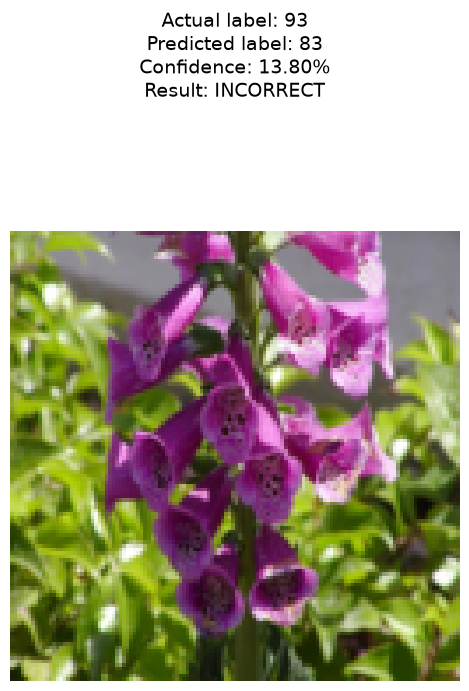

In [92]:
import random
import torch
import matplotlib.pyplot as plt

# Put the transfer-learning model in evaluation mode
transfer_model.eval()

# Choose a random image from the test dataset
image_index = random.randint(0, len(test_dataset) - 1)

image, actual_label = test_dataset[image_index]

# Add a batch dimension:
# [3, 128, 128] becomes [1, 3, 128, 128]
input_image = image.unsqueeze(0).to(device)

# Make the prediction
with torch.no_grad():
    output = transfer_model(input_image)

    probabilities = torch.softmax(output, dim=1)

    predicted_label = torch.argmax(
        probabilities,
        dim=1
    ).item()

    confidence = (
        probabilities[0, predicted_label].item() * 100
    )

# Compare the prediction with the real label
is_correct = predicted_label == actual_label

# Reverse normalization so the image appears normally
mean = torch.tensor(
    [0.485, 0.456, 0.406]
).view(3, 1, 1)

std = torch.tensor(
    [0.229, 0.224, 0.225]
).view(3, 1, 1)

display_image = image.cpu() * std + mean
display_image = torch.clamp(display_image, 0, 1)

# Create the figure
plt.figure(figsize=(7, 7))

# Show information above the image
plt.suptitle(
    f"Actual label: {actual_label}\n"
    f"Predicted label: {predicted_label}\n"
    f"Confidence: {confidence:.2f}%\n"
    f"Result: {'CORRECT' if is_correct else 'INCORRECT'}",
    fontsize=14
)

# Display the image
plt.imshow(display_image.permute(1, 2, 0))
plt.axis("off")

# Leave space above the image for the information
plt.tight_layout(rect=[0, 0, 1, 0.84])

plt.show()

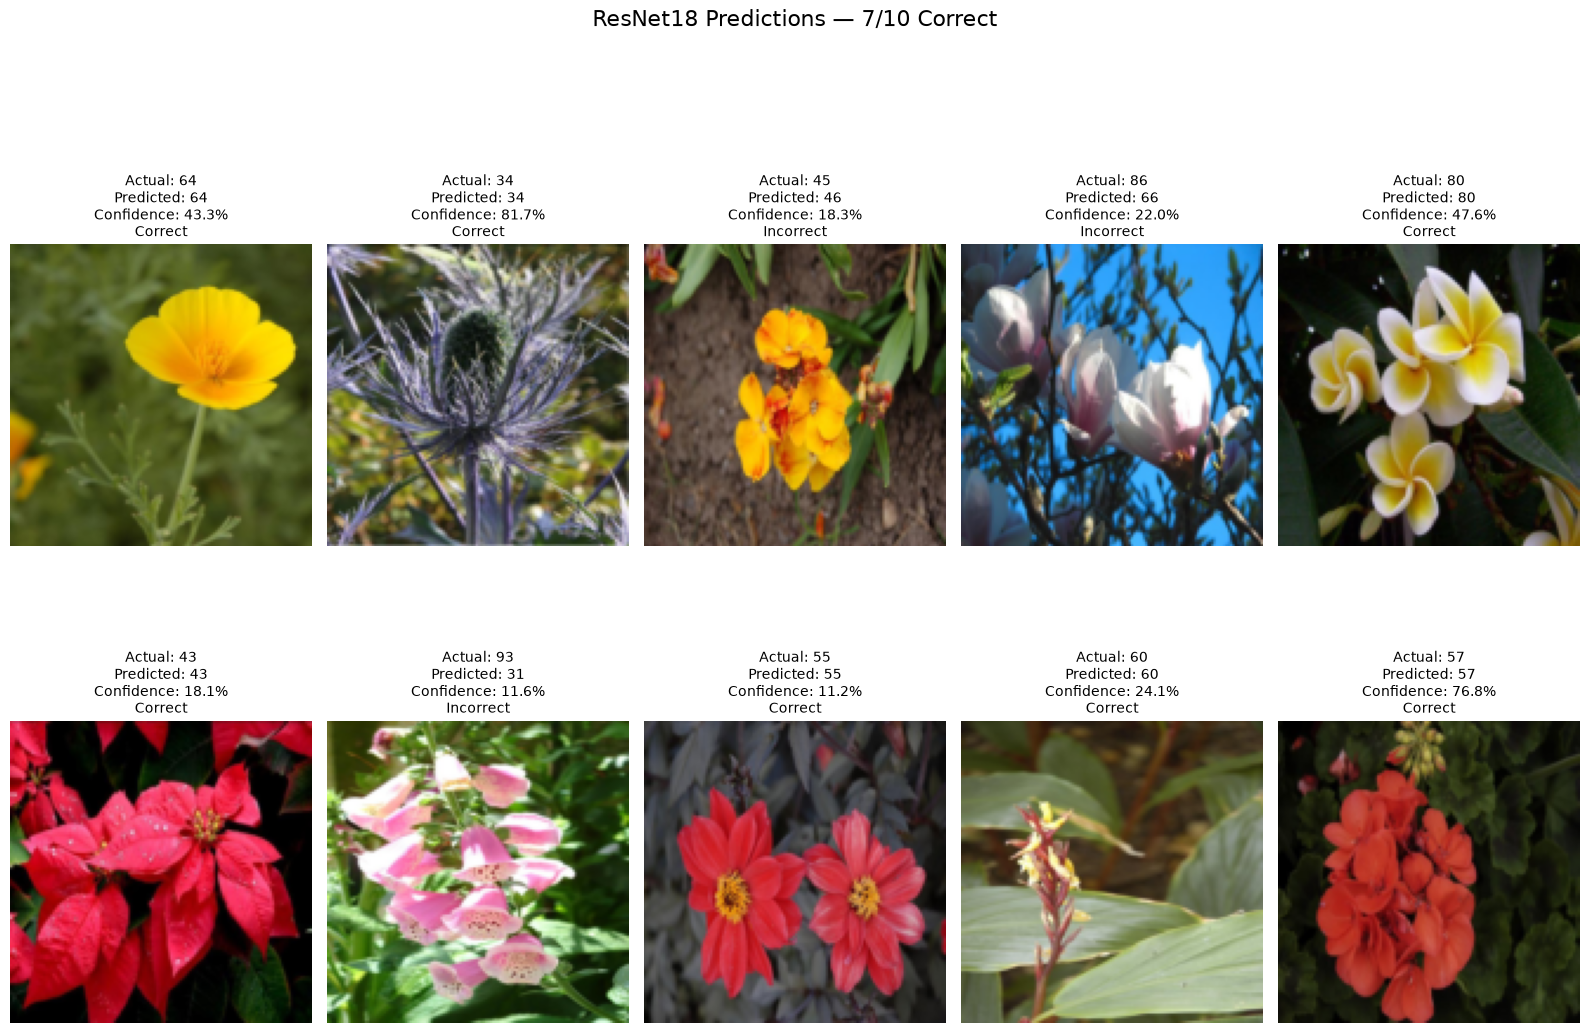

Correct predictions: 7
Accuracy for these 10 images: 70%


In [93]:
import random
import torch
import matplotlib.pyplot as plt

transfer_model.eval()

# Choose 10 different random image indexes
image_indexes = random.sample(
    range(len(test_dataset)),
    10
)

# Values used to reverse normalization
mean = torch.tensor(
    [0.485, 0.456, 0.406]
).view(3, 1, 1)

std = torch.tensor(
    [0.229, 0.224, 0.225]
).view(3, 1, 1)

# Create one figure containing 10 images
plt.figure(figsize=(16, 12))

correct_count = 0

for position, image_index in enumerate(image_indexes):

    # Get one image and its actual label
    image, actual_label = test_dataset[image_index]

    # Add batch dimension
    input_image = image.unsqueeze(0).to(device)

    # Predict
    with torch.no_grad():
        output = transfer_model(input_image)

        probabilities = torch.softmax(
            output,
            dim=1
        )

        predicted_label = torch.argmax(
            probabilities,
            dim=1
        ).item()

        confidence = (
            probabilities[0, predicted_label].item()
            * 100
        )

    # Check whether the prediction is correct
    is_correct = predicted_label == actual_label

    if is_correct:
        correct_count += 1

    # Reverse normalization for displaying the image
    display_image = image.cpu() * std + mean
    display_image = torch.clamp(
        display_image,
        0,
        1
    )

    # Create a 2-row by 5-column arrangement
    plt.subplot(2, 5, position + 1)

    plt.imshow(
        display_image.permute(1, 2, 0)
    )

    plt.title(
        f"Actual: {actual_label}\n"
        f"Predicted: {predicted_label}\n"
        f"Confidence: {confidence:.1f}%\n"
        f"{'Correct' if is_correct else 'Incorrect'}",
        fontsize=10
    )

    plt.axis("off")

plt.suptitle(
    f"ResNet18 Predictions — "
    f"{correct_count}/10 Correct",
    fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print("Correct predictions:", correct_count)
print("Accuracy for these 10 images:", f"{correct_count * 10}%")